We are going to impute the Column for weight, since we have a lot of missing values.

Link to dataset docs: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
Link to imputation methods: https://towardsdatascience.com/different-imputation-methods-to-handle-missing-data-8dd5bce97583/ 

Weight can be the class we're trying to predict, the other features can be used to predict using Models like K-NN.

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
import seaborn as sb

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

seed = 1234
np.random.seed(seed)

X_labels = np.array(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed'])

In [221]:
diabities = pd.read_csv("training_data.csv")

In [222]:
df = pd.DataFrame(diabities)
df

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,...,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,...,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,...,No,No,No,No,No,No,No,No,No,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,89460,289025640,50693553,Caucasian,Male,[80-90),?,1,6,7,...,No,No,No,No,No,No,No,Ch,Yes,NO
91585,60620,169681170,66287709,Caucasian,Male,[50-60),?,5,1,1,...,No,No,No,No,No,No,No,No,Yes,NO
91586,34086,106962006,24745671,Caucasian,Female,[80-90),?,2,1,4,...,No,Steady,No,No,No,No,No,No,Yes,NO
91587,58067,164976492,59602239,Caucasian,Female,[80-90),?,1,1,7,...,No,No,No,No,No,No,No,No,No,>30


In [223]:
df["weight"].unique()

array(['?', '[75-100)', '[100-125)', '[50-75)', '[125-150)', '[25-50)',
       '[0-25)', '[150-175)', '[175-200)', '>200'], dtype=object)

In [224]:
# Creating correlation matrix with Categorical Data

# correlation_matrix = df.corr()

# correlation_matrix

In [225]:
# Create a split for values that are non-null for weight
# df_weight = diabities_with_non_null_weight
df_weight = df[df['weight'] != '?']

In [226]:
df_weight

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
26,20988,73468026,68656032,Caucasian,Male,[70-80),[75-100),3,1,1,...,No,No,No,No,No,No,No,No,No,>30
44,33670,106185540,64203741,Caucasian,Male,[40-50),[100-125),1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
89,71395,206781078,69569415,?,Male,[70-80),[100-125),3,1,1,...,No,Steady,No,No,No,No,No,No,Yes,>30
121,72091,210300636,55808829,Caucasian,Female,[70-80),[75-100),1,6,7,...,No,No,No,No,No,No,No,No,Yes,NO
161,59490,167376852,98844102,Caucasian,Male,[40-50),[100-125),2,1,1,...,No,No,No,No,No,No,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91355,42243,130378080,98531514,Caucasian,Female,[80-90),[75-100),2,3,5,...,No,No,No,No,No,No,No,No,Yes,>30
91449,72520,212251254,33056145,Caucasian,Male,[60-70),[125-150),3,6,1,...,No,No,No,No,No,No,No,No,Yes,>30
91480,28530,93531624,76744422,Caucasian,Female,[50-60),[125-150),3,5,6,...,No,No,No,No,No,No,No,No,Yes,>30
91503,67267,188698692,57147984,Caucasian,Female,[60-70),[75-100),1,1,7,...,No,No,No,No,No,No,No,No,No,NO


### We can observe that our data entries for non-null weights are only 2.8k compared to 91k. We will take this to consideration when using our model for imputation

### Now we have train and test sets for weights

In [227]:
df_weight_tr, df_weight_te = train_test_split(df_weight, train_size=.9, test_size=.1, shuffle=True, random_state=seed)

### We need to do an Ordinal Label Encoder for weights to train our K-NN model

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder


# NOTE! - We have to use OneHotEncoding for nominal values instead of OrdinalEncoding. 
# This we will use Kaveh's ordinality split of columns.

In [ ]:
# NOTE: Make ordinal and nominal together

enc = OrdinalEncoder()
enc.fit(df_weight_tr)

# Encoding for Training Set
encoded_weight_tr = enc.transform(df_weight_tr)
df_encoded_weight_tr = pd.DataFrame(encoded_weight_tr, columns=df_weight_tr.columns)

# Encoding for Testing Set
encoded_weight_te = enc.transform(df_weight_te)
df_encoded_weight_te = pd.DataFrame(encoded_weight_te, columns=df_weight_te.columns)

ValueError: Found unknown categories [np.int64(1294), np.int64(1678), np.int64(2519), np.int64(2799), np.int64(2803), np.int64(2960), np.int64(3007), np.int64(3871), np.int64(4063), np.int64(4151), np.int64(4651), np.int64(6425), np.int64(7624), np.int64(7880), np.int64(7994), np.int64(8110), np.int64(8195), np.int64(8202), np.int64(8907), np.int64(9576), np.int64(10689), np.int64(10798), np.int64(10801), np.int64(11136), np.int64(11369), np.int64(11433), np.int64(11570), np.int64(11739), np.int64(11854), np.int64(13363), np.int64(13459), np.int64(13726), np.int64(14556), np.int64(14986), np.int64(15476), np.int64(15660), np.int64(15798), np.int64(15890), np.int64(16083), np.int64(16158), np.int64(16209), np.int64(17078), np.int64(17712), np.int64(17869), np.int64(18085), np.int64(18215), np.int64(18491), np.int64(18579), np.int64(18952), np.int64(19162), np.int64(20007), np.int64(20858), np.int64(21036), np.int64(21213), np.int64(21660), np.int64(21725), np.int64(21741), np.int64(2193

In [ ]:
df_encoded_weight_tr["weight"]

0       8.0
1       8.0
2       3.0
3       7.0
4       2.0
       ... 
2570    4.0
2571    8.0
2572    4.0
2573    8.0
2574    8.0
Name: weight, Length: 2575, dtype: float64

### Now we construct a correllation matrix

<Axes: >

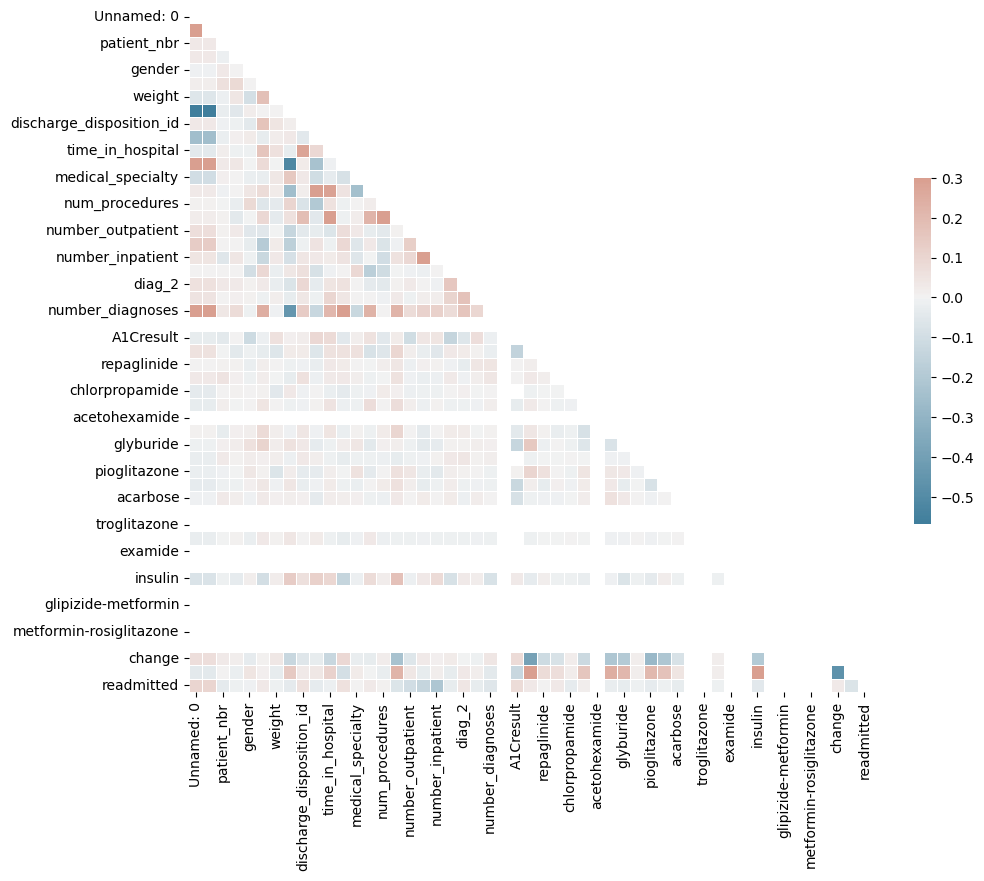

In [ ]:
corr = df_encoded_weight_tr.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sb.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sb.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### Now we extract the features that correlates to weight the most

In [ ]:
# Source - https://stackoverflow.com/a/30863591
# Posted by steboc
# Retrieved 2026-03-04, License - CC BY-SA 3.0

# corr_val=0.01
# df2 = df1.corr().unstack().reset_index()
# df2[df2[0]>corr_val]

corr_val = 0.20
df2 = corr.unstack().reset_index()
df2[df2[0]>corr_val].sort_values(0, ascending=False)


,level_0,level_1,0
0,Unnamed: 0,Unnamed: 0,1.000000
624,medical_specialty,medical_specialty,1.000000
728,num_procedures,num_procedures,1.000000
780,num_medications,num_medications,1.000000
832,number_outpatient,number_outpatient,1.000000
...,...,...,...
1132,number_diagnoses,time_in_hospital,0.210356
2531,diabetesMed,glyburide,0.210142
1681,glyburide,diabetesMed,0.210142
1783,pioglitazone,diabetesMed,0.204867


### KNN to impute the "weight" feature

In [ ]:
df_encoded_weight_tr.drop(columns="weight")

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2417.0,2417.0,1308.0,3.0,1.0,9.0,0.0,2.0,4.0,5.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,2043.0,2043.0,2047.0,3.0,0.0,7.0,0.0,0.0,3.0,1.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,508.0,508.0,1981.0,3.0,1.0,5.0,2.0,0.0,0.0,3.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3,1984.0,1984.0,79.0,3.0,0.0,2.0,0.0,0.0,4.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2523.0,2523.0,2146.0,3.0,0.0,7.0,0.0,0.0,4.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2570,1265.0,1265.0,2122.0,3.0,1.0,4.0,1.0,0.0,0.0,6.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2571,44.0,44.0,1882.0,0.0,1.0,7.0,5.0,0.0,5.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2572,2574.0,2574.0,1841.0,3.0,1.0,6.0,2.0,5.0,0.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2573,960.0,960.0,1043.0,3.0,1.0,6.0,0.0,0.0,4.0,7.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


### We can observe a lot of NaN values for max_glu_serum and A1Cresult
### We can just drop them since the amount of data entries that have those missing values are close to the amount of training data we have.

In [ ]:
df_encoded_weight_tr.isna().sum().sort_values(ascending=False).head(20)

max_glu_serum          2575
A1Cresult              2290
Unnamed: 0                0
nateglinide               0
glimepiride               0
acetohexamide             0
glipizide                 0
glyburide                 0
tolbutamide               0
pioglitazone              0
rosiglitazone             0
acarbose                  0
miglitol                  0
troglitazone              0
tolazamide                0
examide                   0
citoglipton               0
insulin                   0
glyburide-metformin       0
glipizide-metformin       0
dtype: int64

In [ ]:
# We choose an arbitrary value for K
knn = KNeighborsClassifier(n_neighbors=2)

cols_to_remove = ["weight", "max_glu_serum", "A1Cresult"]

y_weight_tr = df_encoded_weight_tr["weight"]
X_weight_tr = df_encoded_weight_tr[df_encoded_weight_tr.columns.difference(cols_to_remove)]

y_weight_te = df_encoded_weight_te["weight"]
X_weight_te = df_encoded_weight_te[df_encoded_weight_te.columns.difference(cols_to_remove)]


In [ ]:
print(X_weight_tr.isna().sum().sum())
print(X_weight_te.isna().sum().sum())

0
0


### Now we are certain we have no NaN values, we can start fitting our data

In [ ]:
knn.fit(X_weight_tr, y_weight_tr)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_weight_pred_tr = knn.predict(X_weight_tr)
print("train: ", accuracy_score(y_weight_tr, y_weight_pred_tr))

y_weight_pred_te = knn.predict(X_weight_te)
print("test: ", accuracy_score(y_weight_te, y_weight_pred_te))

train:  0.6431067961165049
test:  0.18815331010452963
